The data used were from the scDesign3 [example notebooks](https://songdongyuan1994.github.io/scDesign3/docs/articles/scDesign3.html).

## Choosing a distribution

Choose a marginal distribution that matches the support and variability of the feature values. For non-negative integer counts, start with Negative Binomial; use Poisson only when the variance is close to the mean, and consider a zero-inflated model only when there are more zeros than the corresponding count model can explain. Use Bernoulli for binary outcomes and Gaussian for continuous, approximately symmetric measurements.

# Negative Binomial

The Negative Binomial (NB) distribution is the default and a common choice for fitting single-cell raw count data with non-negative integer entires. Besides the copula formula, it allows controlling for the `mean` and `dispersion` of the gene marginal distributions. Its `dispersion` parameter allows it to capture additional biological and technical variability that a Poisson distribution cannot. 

In [18]:
from scdesigner.simulators import NegBinCopula
from scdesigner.datasets import pancreas

example_sce = pancreas()
example_sce

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'counts', 'cpm', 'logcounts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [19]:
sim = NegBinCopula(
    mean_formula="~ bs(pseudotime, df=10)",
    dispersion_formula="~ bs(pseudotime, df=3)",
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 229/500, Loss: 1.8406, Val Loss: 1.8500


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 10.05it/s]


If we want to investigate the fitted marginal model, we can simply call `sim.marginal.parameters`. `sim.marginal` stores the marginal model we fitted on the data, and its `parameter` attribute gives a dictionary of the fitted parameters for modeling `mean` and `dispersion`.

In [20]:
sim.marginal.parameters['mean']

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Intercept,0.486613,-1.341395,-0.750541,-0.179812,4.266025,-2.102801,-3.173024,-0.623416,-2.503333,-2.820455,...,0.178312,-0.340200,1.395179,0.016089,1.200146,-4.238821,-0.858509,1.721486,-4.099339,-0.890871
"bs(pseudotime, df=10)[1]",-1.123380,-0.264637,-2.821198,-0.137428,-0.029184,-1.852767,0.807248,-1.514042,1.368478,-0.892993,...,0.482027,0.253204,0.038124,0.072271,-0.043235,4.424599,1.067176,-0.056019,-1.560924,0.191587
"bs(pseudotime, df=10)[2]",-0.371861,0.760043,0.302288,-0.666165,0.010996,1.070239,0.696356,-0.518554,-0.816655,-0.809726,...,-0.430299,-0.466683,-0.499942,0.671399,-0.100423,4.066035,2.311737,-0.479002,0.580323,-0.086199
"bs(pseudotime, df=10)[3]",-1.452262,-0.043677,-4.073937,-1.286438,-1.071017,-3.389012,5.303135,-1.968036,2.635887,-0.245412,...,1.046768,0.234427,0.929680,2.130616,0.132167,4.961374,3.322949,0.296176,-1.595958,0.376720
"bs(pseudotime, df=10)[4]",-0.761217,-0.059867,1.322045,-1.617004,-7.629449,3.694769,7.232867,-0.808832,1.938195,-0.484778,...,1.314312,1.734242,0.489009,1.271496,-1.236764,4.728755,2.121125,-0.907091,-0.732558,2.436293
"bs(pseudotime, df=10)[5]",0.448167,-0.057947,4.641771,1.324314,-4.581512,5.494165,6.424183,-2.153072,2.928240,-1.216249,...,1.130233,1.620811,-0.000789,0.876121,-1.458498,5.975066,1.744356,-1.576188,0.783895,2.474934
"bs(pseudotime, df=10)[6]",3.301443,0.438381,5.002536,2.548978,-6.310517,5.203084,5.418740,-0.750057,0.704906,0.412520,...,1.104639,1.210958,-1.066570,-0.180914,-1.581383,5.396912,1.133063,-2.559644,-3.746213,1.458608
"bs(pseudotime, df=10)[7]",4.011480,3.163963,4.321770,4.144102,-5.207056,5.201315,4.032784,-1.264610,3.690965,0.371162,...,0.912390,1.298826,-1.015807,-1.152730,-0.027772,4.800032,0.794576,-2.560724,3.124479,0.120526
"bs(pseudotime, df=10)[8]",5.270538,7.490810,4.058055,4.146627,-6.572871,4.890687,4.207917,3.463933,5.946340,6.626876,...,1.399944,0.915431,-0.694791,-0.390480,0.497305,4.723429,1.605612,-1.919711,-4.709215,0.114065
"bs(pseudotime, df=10)[9]",4.503641,6.694267,3.601210,4.102409,-5.089272,4.776501,4.079226,5.530558,6.780347,6.637293,...,1.485917,1.039746,-0.954209,-1.328440,1.232054,4.122941,0.667888,-2.509812,8.913049,0.072791


In [21]:
sim.marginal.parameters['dispersion']

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Intercept,-0.557221,-0.153422,-0.348639,-0.145616,1.503577,-0.000526,0.228073,-0.887780,0.191199,0.400605,...,1.042910,0.311372,0.592191,1.754808,1.779979,0.625336,1.429720,2.117424,-0.849307,0.855785
"bs(pseudotime, df=3)[1]",-0.770811,-0.691453,-1.088739,-1.119117,-1.468734,-1.088874,0.264777,1.150588,-1.717588,-1.737129,...,0.312470,0.024004,1.212165,1.621134,-0.427022,0.192118,0.425993,1.228238,-2.055231,-0.481130
"bs(pseudotime, df=3)[2]",-1.251058,-0.587366,-0.246372,-0.458943,-1.720165,0.673987,-0.172717,-1.243647,-1.371563,-1.515205,...,-1.033538,0.985050,1.334667,0.296272,-0.710573,0.150716,-0.345682,-2.050125,-1.494173,-0.823144
"bs(pseudotime, df=3)[3]",0.604821,1.125710,1.394129,1.572423,-0.721398,0.900835,-0.993711,0.743489,0.593585,0.359393,...,1.031757,-0.471820,1.254887,-0.484429,0.162670,-0.089208,0.523671,-1.744013,-0.385074,0.340276


We can also access the parameters of the copula model by calling `sim.copula.parameters`, which will also give a disctionary. Since we did not assign formula to the copula model while fitting, its `Intercept` element contains the correlations of the genes by default. If we specify categorical variables for the copula formula, the dictionary will contain category-specific correlations across the genes.

In [22]:
sim.copula.parameters['Intercept']

,Pyy,Iapp,Chgb,Rbp4,Spp1,Chga,Cck,Ins1,Nnat,Ins2,...,Nkx6-1,Fxyd3,Hn1,Smarcd2,Pdia6,Ffar2,Hes6,Serpinh1,Npy,1110012L19Rik
Pyy,1.000000,0.063820,-0.125809,0.207865,0.021969,-0.057187,0.091740,-0.018345,-0.013448,-0.018397,...,-0.080728,0.046205,0.051087,0.034532,0.033425,0.013266,0.004339,0.056382,-0.042810,0.007140
Iapp,0.063820,1.000000,0.016822,0.035191,0.032708,0.028550,0.074810,0.039465,0.055470,0.049256,...,0.042369,0.036650,0.069064,0.045354,-0.017948,0.007227,0.032041,-0.035375,-0.021052,0.020256
Chgb,-0.125809,0.016822,1.000000,-0.088935,-0.019149,0.141398,0.043258,-0.009489,0.050111,0.061367,...,0.177739,0.066468,0.038290,0.010144,0.092502,0.080488,0.060970,0.029941,0.031941,0.027978
Rbp4,0.207865,0.035191,-0.088935,1.000000,-0.001482,-0.016436,0.070146,-0.025098,0.047326,-0.019198,...,-0.061898,0.077566,0.026250,-0.013068,0.099534,0.004679,0.001063,0.058924,-0.029483,0.047705
Spp1,0.021969,0.032708,-0.019149,-0.001482,1.000000,0.017775,0.017696,0.037615,0.047255,-0.008821,...,0.055112,0.029016,0.037154,0.003770,0.041982,0.017458,0.028701,0.050235,0.020959,0.059851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ffar2,0.013266,0.007227,0.080488,0.004679,0.017458,0.032461,0.024277,0.046566,-0.000396,0.034320,...,0.041538,0.089180,0.018446,0.054180,0.077546,1.000000,0.033985,-0.016661,-0.006721,0.009447
Hes6,0.004339,0.032041,0.060970,0.001063,0.028701,0.061972,0.051991,0.017730,0.066437,0.045020,...,0.080118,0.035617,0.128928,0.099067,0.072631,0.033985,1.000000,0.070499,-0.024907,0.074669
Serpinh1,0.056382,-0.035375,0.029941,0.058924,0.050235,0.056303,-0.009271,0.041242,0.013485,0.037920,...,0.039983,0.025122,0.076790,0.068979,0.138723,-0.016661,0.070499,1.000000,0.000552,0.032381
Npy,-0.042810,-0.021052,0.031941,-0.029483,0.020959,0.014577,-0.016507,0.054364,-0.003547,0.002780,...,0.054386,-0.004767,0.002779,-0.019716,-0.011601,-0.006721,-0.024907,0.000552,1.000000,0.037235


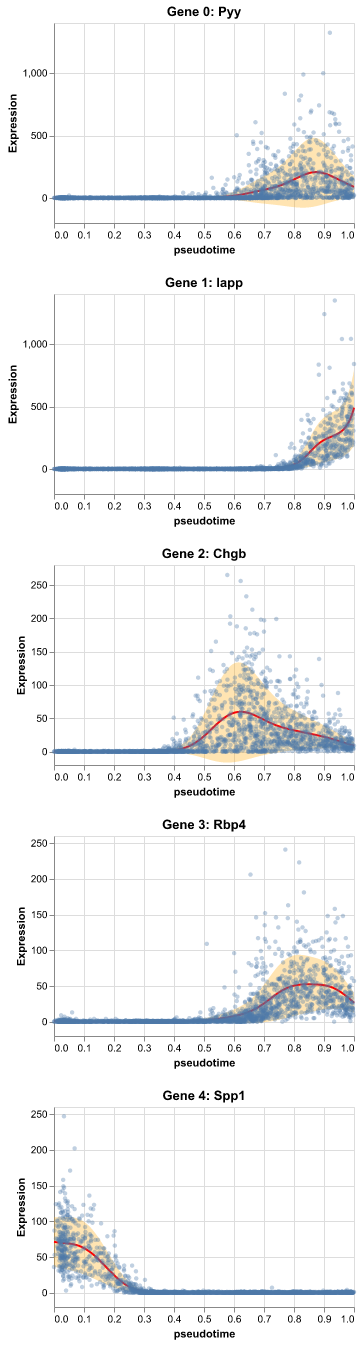

In [23]:
import altair as alt
import scipy.sparse
import pandas as pd
import numpy as np
alt.data_transformers.enable("vegafusion")
alt.renderers.enable('png')


def visualize_gene_expression(sim, sce, num_genes=5, var="pseudotime"):
    """Visualize observed and fitted expression against a numeric ``sce.obs`` covariate."""
    if var not in sce.obs.columns:
        raise KeyError(f"{var!r} is not a column in sce.obs")

    charts = []
    expression = sce.X.toarray() if scipy.sparse.issparse(sce.X) else np.asarray(sce.X)
    predictions = sim.predict(sce.obs)

    for ix in range(min(num_genes, sce.n_vars)):
        gene = sce.var_names[ix]
        y_hat = pd.DataFrame({
            var: sce.obs[var].to_numpy(),
            "mean": predictions["mean"][:, ix],
        })

        # Calculate variance and one-standard-deviation intervals.
        if "dispersion" in predictions:
            y_hat["dispersion"] = predictions["dispersion"][:, ix]
            variance = y_hat["mean"] + (y_hat["mean"] ** 2) / y_hat["dispersion"]
        else:
            # Poisson fallback: Var(Y) = E(Y) = mean.
            variance = y_hat["mean"]
        y_hat["lower_sd"] = y_hat["mean"] - np.sqrt(variance)
        y_hat["upper_sd"] = y_hat["mean"] + np.sqrt(variance)

        observed = pd.DataFrame({
            var: sce.obs[var].to_numpy(),
            "expression": expression[:, ix],
        })
        x = alt.X(field=var, type="quantitative", title=var)

        points = alt.Chart(observed).mark_circle(size=20, opacity=0.35).encode(
            x=x,
            y=alt.Y("expression:Q", title="Expression"),
        )

        fitted = y_hat.sort_values(var)
        interval = alt.Chart(fitted).mark_area(opacity=0.3, color="orange").encode(
            x=x,
            y=alt.Y("lower_sd:Q", title="Expression"),
            y2="upper_sd:Q",
        )
        fitted_values = alt.Chart(fitted).mark_line(color="red").encode(
            x=x,
            y=alt.Y("mean:Q", title="Expression"),
        )

        chart = (interval + fitted_values + points).properties(
            title=f"Gene {ix}: {gene}",
            width=300,
            height=200,
        )
        charts.append(chart)

    return alt.vconcat(*charts)

# Set var to any numeric column in example_sce.obs
visualize_gene_expression(sim, example_sce, num_genes=5, var="pseudotime")

We can see that the fitted mean and variance bands can well capture the distribution of the real gene expressions.

In [24]:
import scipy.sparse as sp

# Compare real vs simulated expression data
def compare_gene_expression(sim, sce, num_genes=5, var="pseudotime"):
    """Compare real vs simulated expression data with jitter"""
    charts = []
    real_X = sce.X.toarray() if sp.issparse(sce.X) else np.asarray(sce.X)
    for ix in range(num_genes):
        gene = sce.var_names[ix]
        sampled = sim.sample(sce.obs)

        # Prepare data for plotting
        real_data = pd.DataFrame({ var: sce.obs[var], 'expression': real_X[:, ix], 'type': 'real' })
        sim_data = pd.DataFrame({ var: sce.obs[var], 'expression': sampled.X[:, ix], 'type': 'simulated' })
        combined_data = pd.concat([real_data, sim_data])

        # Create chart
        chart = alt.Chart(combined_data).mark_circle(size=20, opacity=0.3).encode(
            x=f'{var}:Q',
            y='expression:Q',
            color='type:N'
        ).properties(
            title=f'Gene {ix}: {gene}',
            width=300,
            height=200
        )

        charts.append(chart)

    # Display charts
    return alt.vconcat(*charts)

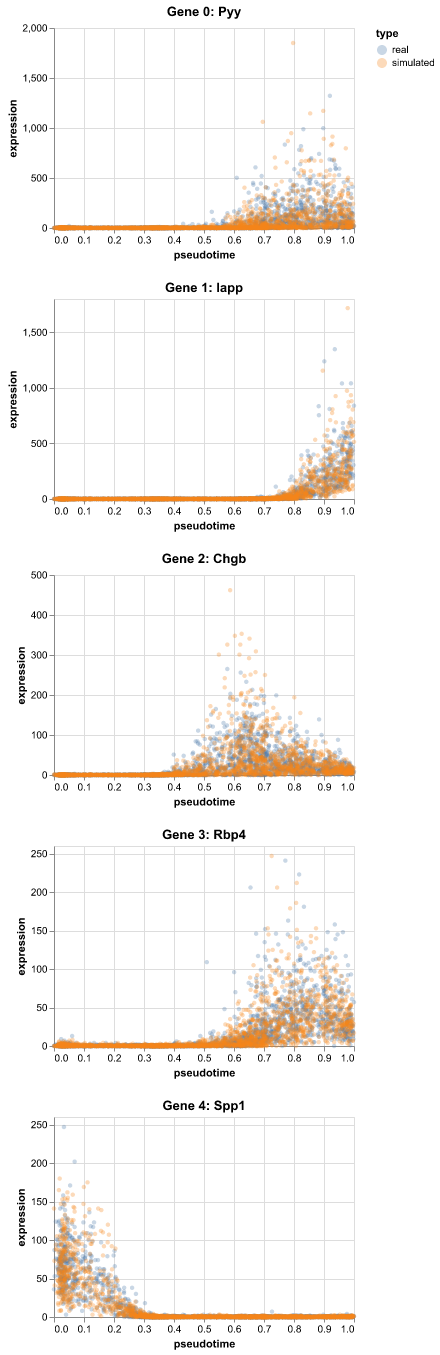

In [25]:
compare_gene_expression(sim, example_sce, num_genes=5)

The simulated data is also well mixed with the real data expression.

# Poisson

We can use the Poisson distribution for non-negative integer counts when the conditional variance is approximately equal to the conditional mean. It is a useful simple baseline, but it may underestimate variability in overdispersed single-cell data; in that case, we would prefer NB.

In [26]:
from scdesigner.simulators import PoissonCopula

sim = PoissonCopula("~ pseudotime")
sim.fit(example_sce)
sim

Epoch 49/500, Loss: 3.8208, Val Loss: 3.8740


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 15.54it/s]


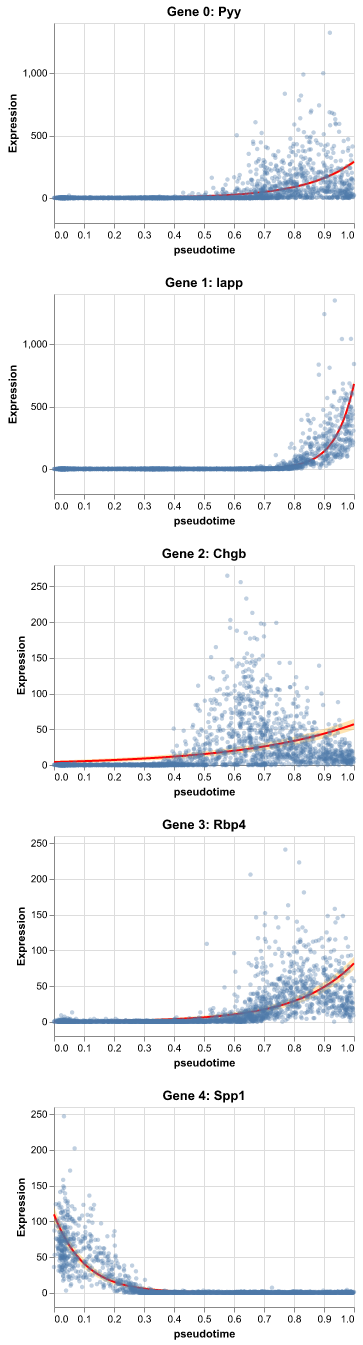

In [27]:
# Visualize Poisson model
visualize_gene_expression(sim, example_sce, num_genes=5)

We can see that in this case, the means are still well fitted for some genes, but the variance fails to capture the variability in the expressions. In some cases, the fitted curves are also less flexible, especially for genes where the dispersion of the expressions varies with pseudotime. This suggests that using a NB model may be more appropriate.

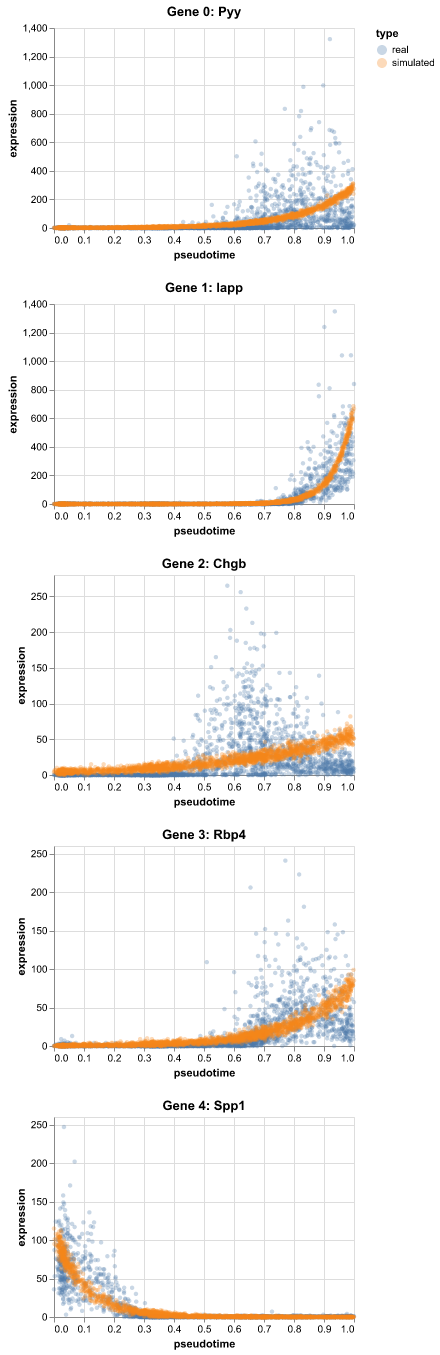

In [28]:
# Compare real vs simulated data
compare_gene_expression(sim, example_sce, num_genes=5)

The simulated data is also unable to reflect the real gene expressions.

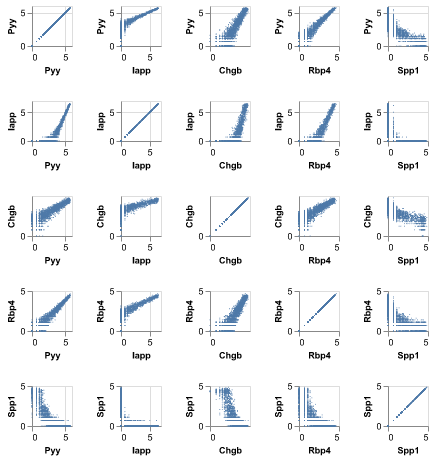

In [29]:
# plotting correlation of simulated data, compare with real by substituting sampled = example_sce
sampled = sim.sample()
X = pd.DataFrame(np.log(1 + sampled.X), columns=sampled.var_names, index=sampled.obs.index)

sampled_subset = pd.concat([X.iloc[:, :5], sampled.obs], axis=1)
alt.Chart(sampled_subset).mark_circle(opacity=1, size=1).encode(
    alt.X(alt.repeat("column"), type='quantitative'),
    alt.Y(alt.repeat("row"), type='quantitative')
).properties(width=40, height=40).repeat(
    row=sampled_subset.columns[:5],
    column=sampled_subset.columns[:5]
).configure_axis(labelFontSize=9, titleFontSize=9)

# Zero-Inflated Poisson

In cases where the raw count data has more zeros than a plain Poisson model can explain, but the non-zero count component is otherwise reasonably Poisson-like, we can use Zero-Inflated Poisson (ZIP) model to account for the additional zero-inflation information. We should also note that excess zeros can also arise from overdispersion, in which case NB or a zero-inflated NB can be more useful.

In [30]:
from scdesigner.simulators import ZeroInflatedPoissonCopula
from scdesigner.datasets import granja_atac

example_sce = granja_atac()
example_sce

AnnData object with n_obs × n_vars = 7034 × 1133
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'passed_filters', 'cell_id', 'is__cell_barcode', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'peaks_snn_res.0.8', 'seurat_clusters', 'ident', 'cell_type'
    obsm: 'LSI', 'UMAP'

In [31]:
sim = PoissonCopula(
    mean_formula="~ cell_type",
    copula_formula="~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 189/500, Loss: 0.3775, Val Loss: 0.3823


Estimating copula correlation: 100%|██████████| 7/7 [00:01<00:00,  3.61it/s]


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import sparse


def compare_histogram2(
    adata_real,
    adata_sim,
    genes=None,
    n_genes=10,
    random_state=0,
    max_count=None,
    figsize=None
):
    assert adata_real.var_names.equals(adata_sim.var_names), \
        "Real and simulated genes must match"

    rng = np.random.default_rng(random_state)

    # select genes
    if genes is None:
        genes = rng.choice(
            adata_real.var_names,
            size=n_genes,
            replace=False
        )

    n = len(genes)

    ncols = 5
    nrows = math.ceil(n / ncols)

    if figsize is None:
        figsize = (4*ncols, 3*nrows)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False
    )

    axes = axes.flatten()

    for ax, gene in zip(axes, genes):

        idx = adata_real.var_names.get_loc(gene)

        # extract counts
        real = adata_real.X[:, idx]
        sim = adata_sim.X[:, idx]

        if sparse.issparse(real):
            real = real.toarray().ravel()
        else:
            real = np.asarray(real).ravel()

        if sparse.issparse(sim):
            sim = sim.toarray().ravel()
        else:
            sim = np.asarray(sim).ravel()


        # make integer bins
        if max_count is None:
            xmax = int(max(real.max(), sim.max()))
        else:
            xmax = max_count

        bins = np.arange(-0.5, xmax + 1.5, 1)

        ax.hist(
            real,
            bins=bins,
            alpha=0.5,
            label="real",
            density=False
        )

        ax.hist(
            sim,
            bins=bins,
            alpha=0.5,
            label="simulated",
            density=False
        )

        ax.set_title(gene, fontsize=8)
        ax.set_xlabel("count")
        ax.set_ylabel("number of cells")

        ax.set_xticks(
            np.arange(0, xmax+1)
        )

        ax.legend(fontsize=8)


    # remove unused axes
    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

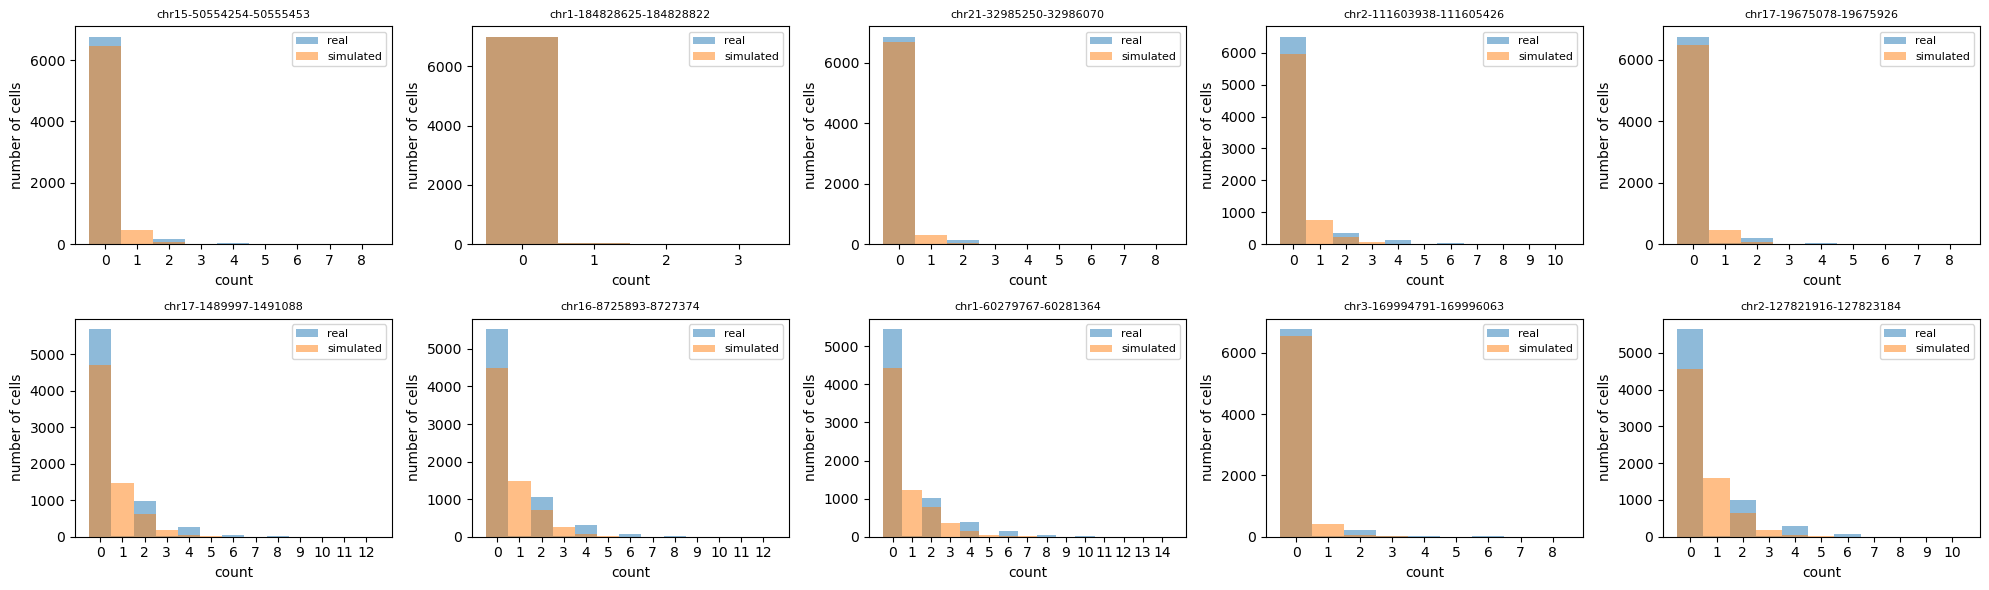

In [33]:
compare_histogram2(example_sce, sampled_sce)

First fitting the data using simply Poisson distribution suggests that the model fails to capture the excessive zeros in many of the genes. In this case we can turn to `ZeroInflatedPoissonCopula`, which allows an additional `zero_inflation` parameter.

In [34]:
sim = ZeroInflatedPoissonCopula(
    mean_formula="~ cell_type",
    zero_inflation_formula="~ cell_type",
    copula_formula="~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 500/500, Loss: 0.2745, Val Loss: 0.2812


Estimating copula correlation: 100%|██████████| 7/7 [00:02<00:00,  3.33it/s]


We can also access the fitted coefficients of the `zero_inflation` parameter using `sim.marginal.parameters`.

In [35]:
sim.marginal.parameters['zero_inflation']

,chr6-44025105-44028184,chr2-113581628-113594911,chr6-41236364-41244047,chr20-48889794-48893313,chr6-44031788-44032972,chr20-1923912-1928154,chr15-93346770-93347989,chr2-113596703-113597906,chr3-46130424-46132103,chr19-47891861-47893634,...,chr8-21336556-21336818,chr4-25987003-25987275,chr2-8726063-8726568,chr1-53758476-53758638,chr4-785863-787006,chr16-58459697-58460545,chr16-67973505-67974483,chr1-222112920-222113382,chr2-233174300-233175622,chr3-13015237-13015864
Intercept,-0.736033,-0.823559,-0.288491,-0.612631,0.023922,-0.168845,-0.124682,-0.021827,-0.002641,-0.026368,...,-0.514726,-0.979577,4.067629,-0.471655,-0.797022,2.572019,-0.263451,-1.149026,-1.159225,0.217577
cell_type[T.CD4 Memory],3.637552,3.952273,3.487314,3.658535,3.266497,3.526539,3.003359,3.495190,3.053018,3.288145,...,5.313572,13.754503,0.047369,13.808475,3.465938,1.977397,3.315860,13.909225,4.250869,3.610627
cell_type[T.CD8 Effector],3.699995,3.857640,3.472897,3.938473,3.910842,3.545830,3.419562,3.670452,3.807677,3.521417,...,-4.006831,13.688698,0.566306,-5.395673,3.800569,1.846156,3.210339,6.719480,3.542906,2.727405
cell_type[T.CD4 Naive],3.420079,3.681332,2.925989,3.327256,3.634970,3.051765,3.229184,3.274522,2.731407,3.070937,...,4.467335,13.729508,0.615783,-4.731961,3.565109,2.003915,2.642747,13.890552,4.604979,3.919223
cell_type[T.DN T],4.208298,4.259256,4.240974,4.476073,4.140140,3.692304,4.028494,3.887124,3.670248,3.861383,...,13.400881,13.698695,0.950350,13.750323,5.093308,3.144514,2.986308,7.000884,3.763016,-2.620924
cell_type[T.CD8 Naive],3.517964,3.756669,3.926525,3.797214,2.991641,3.402603,3.385998,3.152104,2.979276,3.184963,...,-3.118730,13.708824,-2.923316,-4.000703,3.447453,2.141851,3.580067,13.876027,4.140265,-2.662537
cell_type[T.NK CD56Dim],3.547505,3.503773,3.042940,3.252526,3.029569,3.592264,2.786236,3.613778,3.214007,2.928204,...,13.401140,13.699748,2.900053,-3.447213,-2.147788,0.605147,3.605538,6.660428,3.006132,2.932980
cell_type[T.pre-B],3.523079,3.494737,2.840116,3.250609,3.206767,2.517626,3.622992,2.650012,3.359497,2.788152,...,13.389573,4.411643,-0.209135,4.953553,5.075440,1.180691,3.205278,2.940765,5.893975,3.332382
cell_type[T.CD16 Mono],1.600245,1.120748,0.373510,-0.268319,1.439630,0.393938,0.737365,0.744562,0.545521,0.161852,...,13.350294,-3.097343,10.369871,13.703384,5.251641,-0.693243,12.589612,-2.881463,6.367573,4.023151
cell_type[T.pro-B],3.628581,3.363440,3.286902,3.625065,3.648149,2.867438,3.251927,2.809846,2.588222,3.532418,...,3.708356,3.290926,1.409171,5.512854,4.681355,0.682374,3.242281,3.130936,6.532353,2.559529


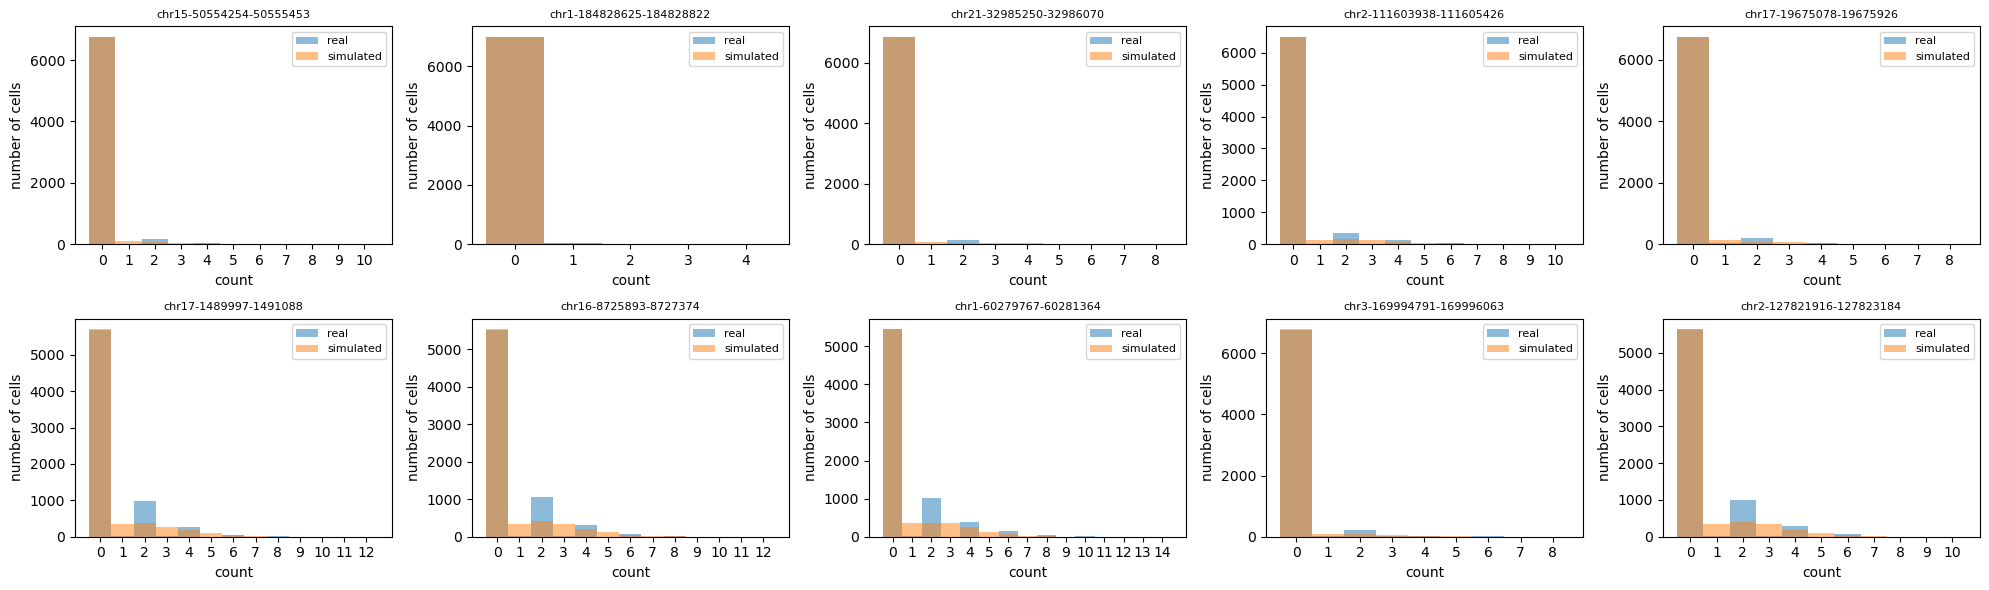

In [36]:
compare_histogram2(example_sce, sampled_sce)

The model now captures the excessive zeros in the oritinal data.

# Zero-Inflated Negative Binomial

In some cases, the data can contain both an excess in the variability (overdispersion) and an excess of zeros (zero-inflation), in which case a zero-inflated Negative Binomial model may be appropriate.

In [37]:
from scdesigner.simulators import ZeroInflatedNegBinCopula

sim = ZeroInflatedNegBinCopula(
    mean_formula="~ cell_type",
    zero_inflation_formula="~ cell_type",
    copula_formula="~ 1"
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 500/500, Loss: 0.2714, Val Loss: 0.2774


Estimating copula correlation: 100%|██████████| 7/7 [00:02<00:00,  3.03it/s]


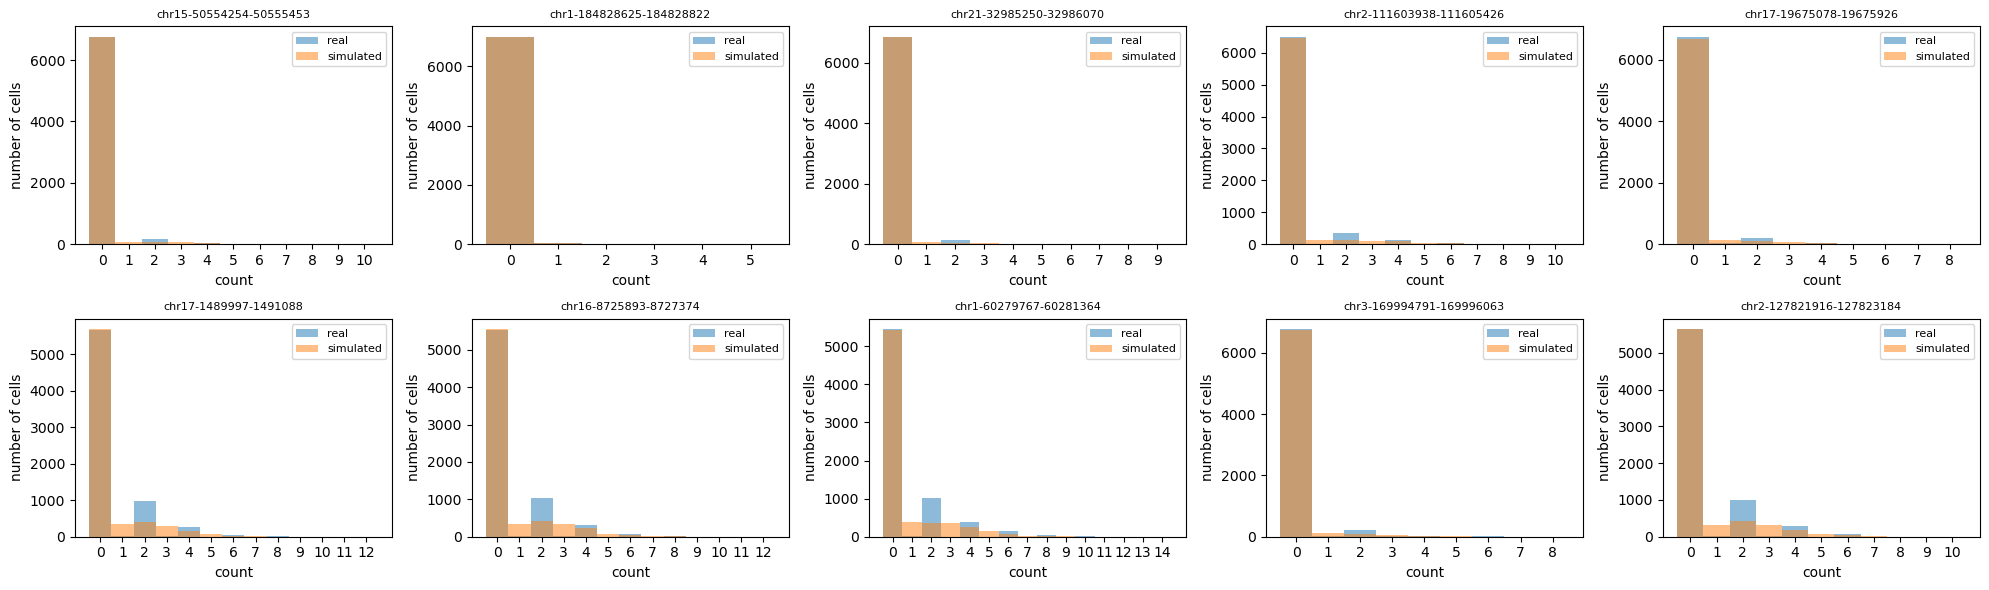

In [38]:
compare_histogram2(example_sce, sampled_sce)

Since the example count matrix here is not a dispersed dataset, using a NB model may be an overkill and introduce unnecessary outliers. In this case, a ZIP model may be enough.

# Bernoulli

We can use the Bernoulli distribution when each feature is binary (0 or 1), such as detected/not detected, accessible/inaccessible, or methylated/unmethylated measurements. It models the probability of a positive outcome rather than the magnitude of a count.

In [39]:
from scdesigner.simulators import BernoulliCopula
from scdesigner.datasets import scgemmeth

example_sce = scgemmeth()
example_sce

AnnData object with n_obs × n_vars = 142 × 27
    obs: 'X1', 'X2', 'X3', 'X4', 'X5', 'cell_type', 'UMAP1_integrated', 'UMAP2_integrated'
    layers: 'counts'

In [40]:
sim = BernoulliCopula(
    mean_formula = "~ bs(X2, df=3)" # formula?
)
sim.fit(example_sce)
sampled_sce = sim.sample()

Epoch 500/500, Loss: 0.4322, Val Loss: 0.4680


Estimating copula correlation: 100%|██████████| 1/1 [00:00<00:00, 43.11it/s]


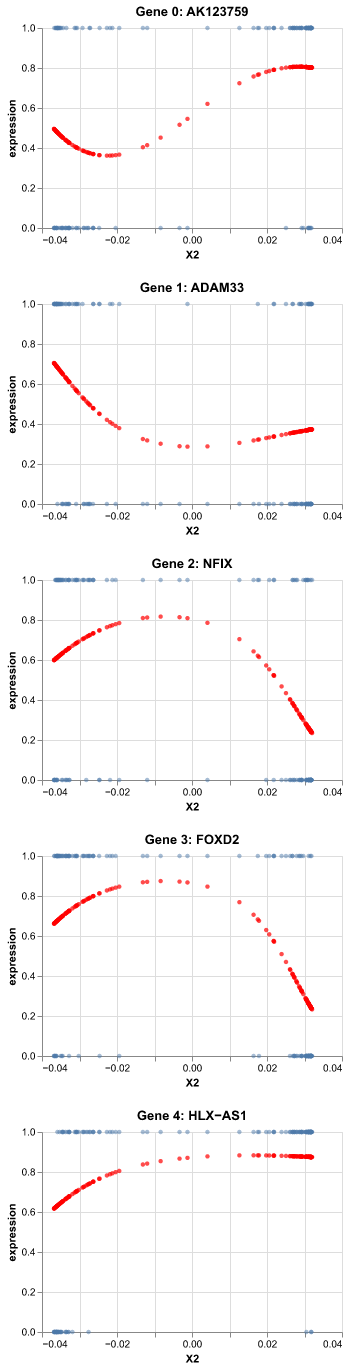

In [41]:
# Visualize Bernoulli model
def visualize_bernoulli_expression(sim, sce, num_genes=5, var="X2"):
    """Visualize Bernoulli expression probabilities"""
    charts = []

    for ix in range(num_genes):
        gene = sce.var_names[ix]

        # Get predictions
        predictions = sim.predict(sce.obs)
        y_hat = pd.DataFrame({ var: sce.obs[var], 'probability': predictions['mean'][:, ix] })

        # Prepare data for plotting
        plot_data = pd.DataFrame({var: sce.obs[var], 'expression': sce.X[:, ix], 'type': 'observed'})
        prediction_data = pd.DataFrame({var: y_hat[var], 'expression': y_hat['probability'], 'type': 'predicted'})
        combined_data = pd.concat([plot_data, prediction_data])

        # Create chart
        base = alt.Chart(combined_data).encode(
            x=f'{var}:Q',
            y='expression:Q'
        ).properties(
            title=f'Gene {ix}: {gene}',
            width=300,
            height=200
        )

        points_obs = base.mark_circle(size=20, opacity=0.5).transform_filter(
            alt.datum.type == 'observed'
        )

        points_pred = base.mark_circle(size=20, color='red').transform_filter(
            alt.datum.type == 'predicted'
        )

        chart = (points_obs + points_pred)
        charts.append(chart)

    # Display charts
    return alt.vconcat(*charts)

# Visualize Bernoulli genes
visualize_bernoulli_expression(sim, example_sce, num_genes=5)

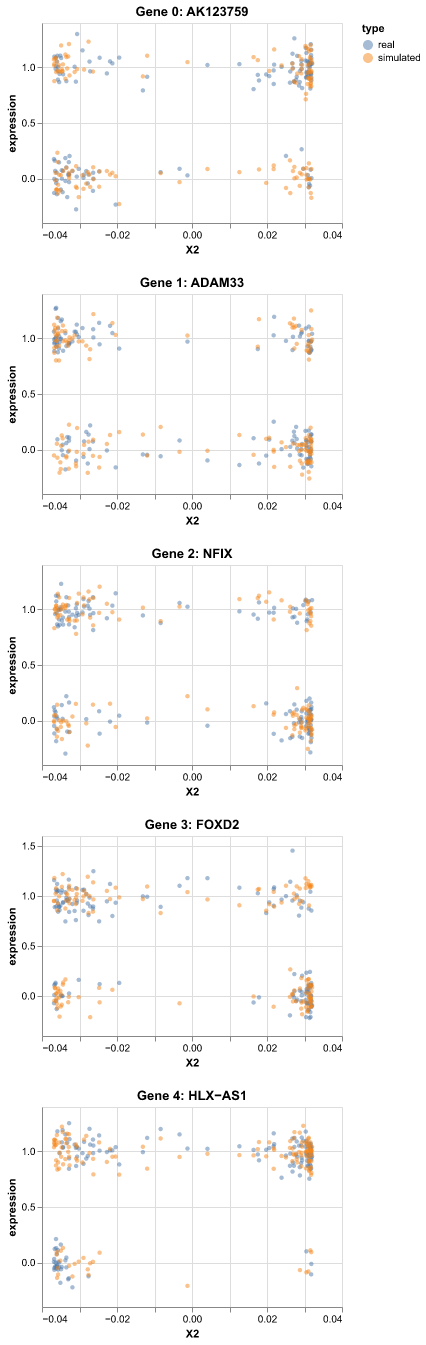

In [42]:
# Compare real vs simulated Bernoulli data
def compare_bernoulli_data(sim, sce, num_genes=5, var="X2"):
    """Compare real vs simulated Bernoulli data with jitter"""
    charts = []

    for ix in range(num_genes):
        gene = sce.var_names[ix]
        sampled = sim.sample(sce.obs)

        # Add jitter to avoid overplotting
        jitter_real = sce.X[:, ix] + np.random.normal(0, 0.1, sce.X.shape[0])
        jitter_sim = sampled.X[:, ix] + np.random.normal(0, 0.1, sampled.X.shape[0])

        # Prepare data for plotting
        real_data = pd.DataFrame({ var: sce.obs[var], 'expression': jitter_real, 'type': 'real' })
        sim_data = pd.DataFrame({ var: sce.obs[var], 'expression': jitter_sim, 'type': 'simulated' })
        combined_data = pd.concat([real_data, sim_data])

        # Create chart
        chart = alt.Chart(combined_data).mark_circle(size=20, opacity=0.5).encode(
            x=f'{var}:Q',
            y='expression:Q',
            color='type:N'
        ).properties(
            title=f'Gene {ix}: {gene}',
            width=300,
            height=200
        )

        charts.append(chart)

    # Display charts
    return alt.vconcat(*charts)

compare_bernoulli_data(sim, example_sce, num_genes=5)

# Gaussian

When the input matrix is continuous and approximately symmetric without limitation of negativity (such as log-normalized count matrix), we can use the Gaussian distribution for model fitting. It is generally not suitable for raw counts because it does not preserve discreteness or non-negativity.

In [43]:
from scdesigner.simulators import GaussianCopula
from scdesigner.datasets import scgemrna

example_sce = scgemrna()
example_sce.X

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 23.89093845],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         7.84973772, 22.45530337],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        11.45149369, 23.17366107],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         3.63948018,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 17.11715217],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         6.10887974, 19.27383326]])

Epoch 10/500, Loss: 2.2877, Val Loss: 2.2703


Estimating copula correlation: 100%|██████████| 1/1 [00:00<00:00, 39.69it/s]


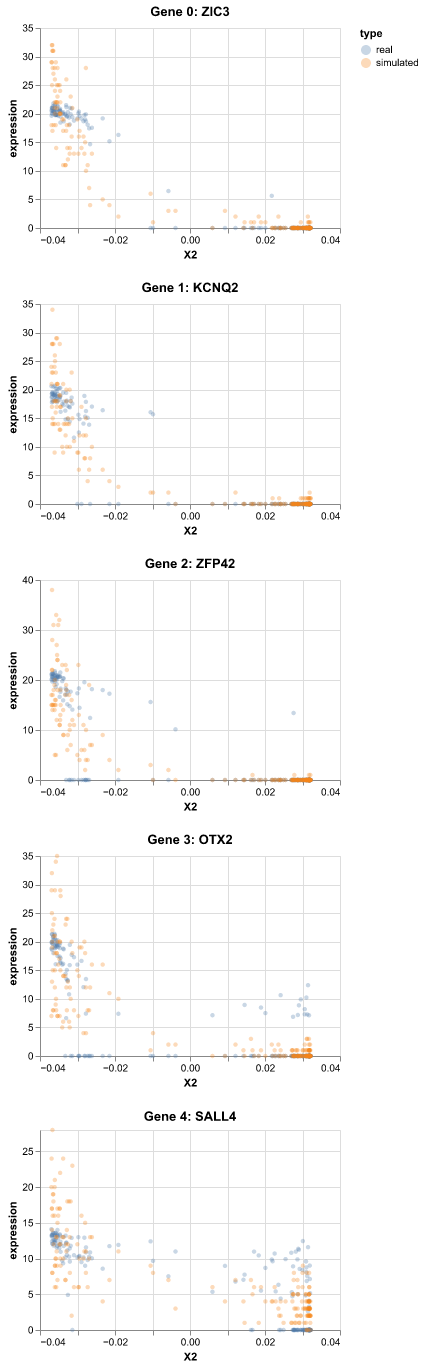

In [44]:
negbin_sim = NegBinCopula(
    mean_formula="~ X2"
)
negbin_sim.fit(example_sce)
compare_gene_expression(negbin_sim, example_sce, num_genes=5, var="X2")

Since the count matrix is no longer discrete, we can fit the model using `GaussianCopula`. It also contains a parameter to control for its variance, but unlike `NegBinCopula` which uses `dispersion_formula`, `GaussianCopula` now uses `sdev_formula`, and we can access its standard deviation coefficients using `sim.marginal.parameters['sdev']`.

In [45]:
gaussian_sim = GaussianCopula(
    mean_formula="~ bs(X2, df=10)",
    sdev_formula="~ bs(X2, df=3)"
)
gaussian_sim.fit(example_sce)

Epoch 500/500, Loss: 4.5038, Val Loss: 5.918735


Estimating copula correlation: 100%|██████████| 1/1 [00:00<00:00, 35.82it/s]


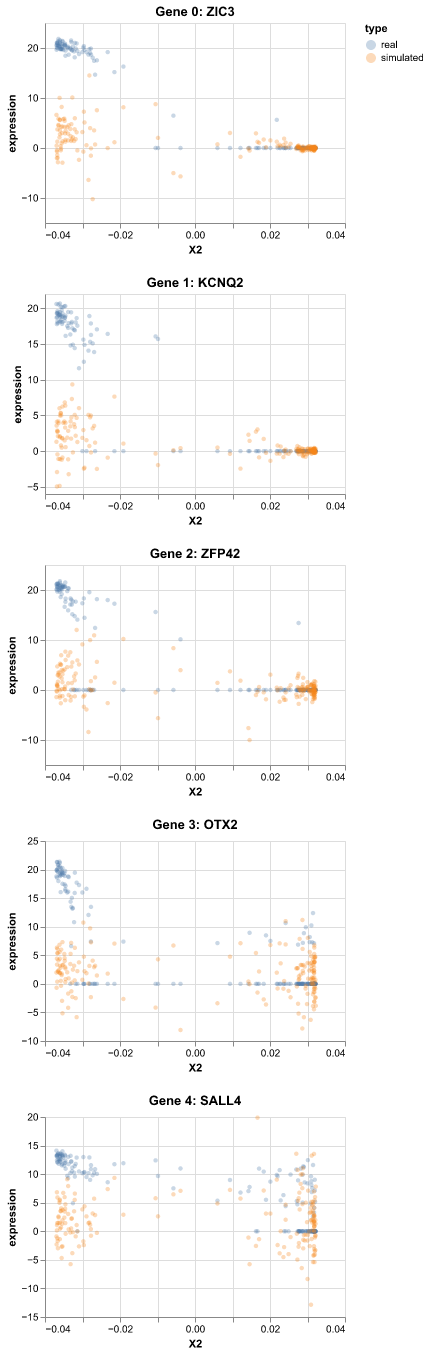

In [46]:
compare_gene_expression(gaussian_sim, example_sce, num_genes=5, var="X2")

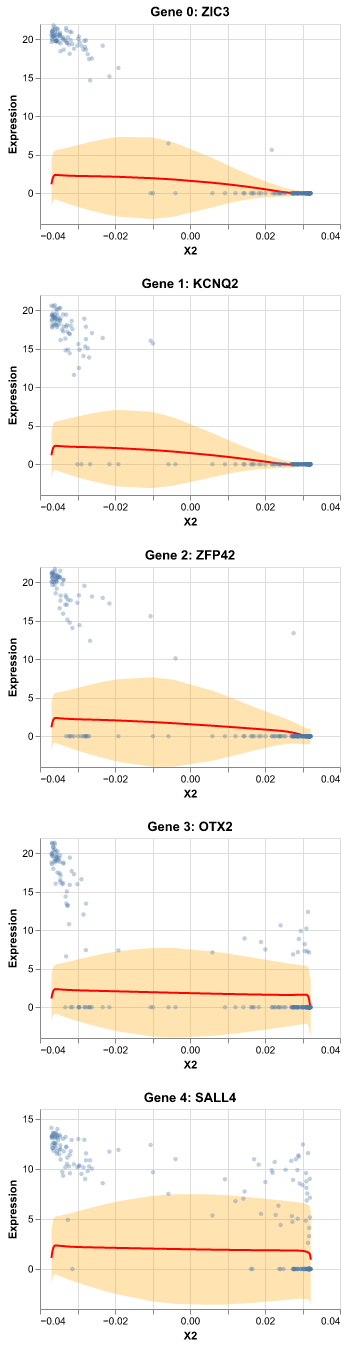

In [47]:
def visualize_gaussian_expression(
    sim, sce, num_genes=5, var="X2", n_sdev=1.0
):
    """Plot fitted Gaussian means and mean +/- ``n_sdev`` standard deviations."""
    if var not in sce.obs.columns:
        raise KeyError(f"{var!r} is not a column in sce.obs")
    if n_sdev <= 0:
        raise ValueError("n_sdev must be positive")

    predictions = sim.predict(sce.obs)
    if "mean" not in predictions or "sdev" not in predictions:
        raise ValueError("The fitted model must provide both 'mean' and 'sdev'")

    expression = (
        sce.X.toarray() if scipy.sparse.issparse(sce.X) else np.asarray(sce.X)
    )
    x = alt.X(field=var, type="quantitative", title=var)
    charts = []

    for ix in range(min(num_genes, sce.n_vars)):
        gene = sce.var_names[ix]
        observed = pd.DataFrame({
            var: sce.obs[var].to_numpy(),
            "expression": expression[:, ix],
        })
        fitted = pd.DataFrame({
            var: sce.obs[var].to_numpy(),
            "mean": predictions["mean"][:, ix],
            "sdev": predictions["sdev"][:, ix],
        }).sort_values(var)
        fitted["lower"] = fitted["mean"] - n_sdev * fitted["sdev"]
        fitted["upper"] = fitted["mean"] + n_sdev * fitted["sdev"]

        points = alt.Chart(observed).mark_circle(size=20, opacity=0.35).encode(
            x=x,
            y=alt.Y("expression:Q", title="Expression"),
        )
        band = alt.Chart(fitted).mark_area(opacity=0.3, color="orange").encode(
            x=x,
            y=alt.Y("lower:Q", title="Expression"),
            y2="upper:Q",
        )
        mean_line = alt.Chart(fitted).mark_line(color="red").encode(
            x=x,
            y=alt.Y("mean:Q", title="Expression"),
        )

        charts.append(
            (band + mean_line + points).properties(
                title=f"Gene {ix}: {gene}",
                width=300,
                height=200,
            )
        )

    return alt.vconcat(*charts)


# n_sdev=1 gives the central approximately 68% Gaussian prediction band.
visualize_gaussian_expression(
    gaussian_sim, example_sce, num_genes=5, var="X2"
)

### Test using log-normalized pancreas data.

Since the previous Gaussian model did not fit well, I also tested it with log-normalized pancreas dataset.

In [155]:
import scanpy as sc

gaussian_sce = pancreas().copy()
sc.pp.normalize_total(gaussian_sce, target_sum=1e4)
sc.pp.log1p(gaussian_sce)
gaussian_sce

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'counts', 'cpm', 'logcounts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [156]:
gaussian_sce.X.todense()

matrix([[7.63897487, 0.        , 7.45868832, ..., 3.05217358, 0.        ,
         0.        ],
        [3.28492349, 0.        , 3.95917148, ..., 3.28492349, 0.        ,
         5.19821294],
        [0.        , 3.5808491 , 5.80690489, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [7.0797814 , 0.        , 6.92132107, ..., 2.82273421, 0.        ,
         2.82273421],
        [0.        , 0.        , 6.75816222, ..., 3.40633479, 0.        ,
         3.40633479],
        [0.        , 0.        , 3.0814521 , ..., 4.83421728, 0.        ,
         4.14899155]])

Epoch 10/500, Loss: 1.7007, Val Loss: 1.6822


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 13.19it/s]


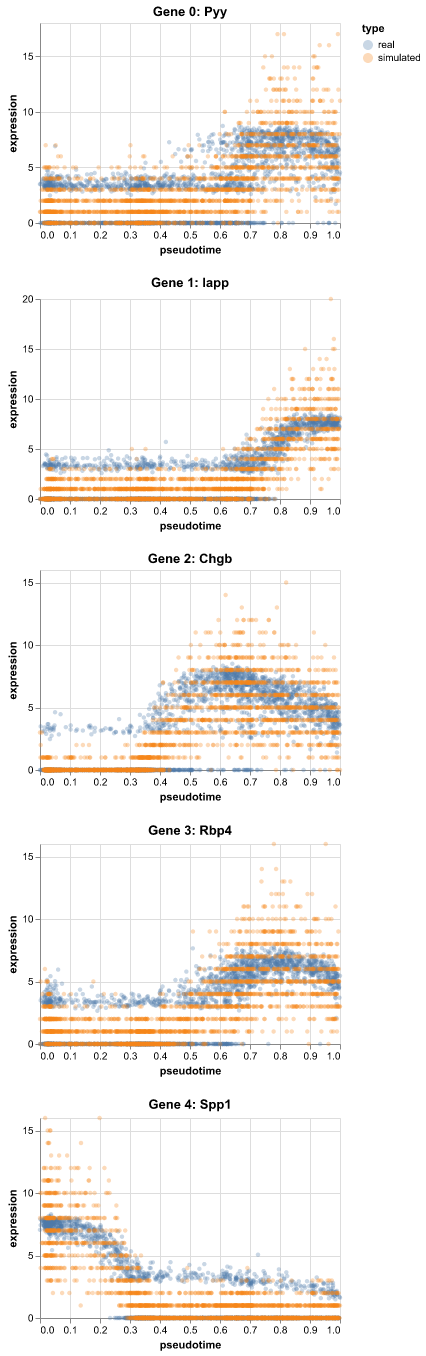

In [157]:
negbin_sim = NegBinCopula(
    mean_formula="~ bs(pseudotime, df=10)"
)
negbin_sim.fit(gaussian_sce)
compare_gene_expression(negbin_sim, gaussian_sce, num_genes=5, var="pseudotime")

In [158]:
gaussian_sim = GaussianCopula(
    mean_formula="~ bs(pseudotime, df=10)",
    sdev_formula="~ bs(pseudotime, df=3)"
)
gaussian_sim.fit(gaussian_sce)

Epoch 500/500, Loss: 1.8413, Val Loss: 1.8363


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 15.00it/s]


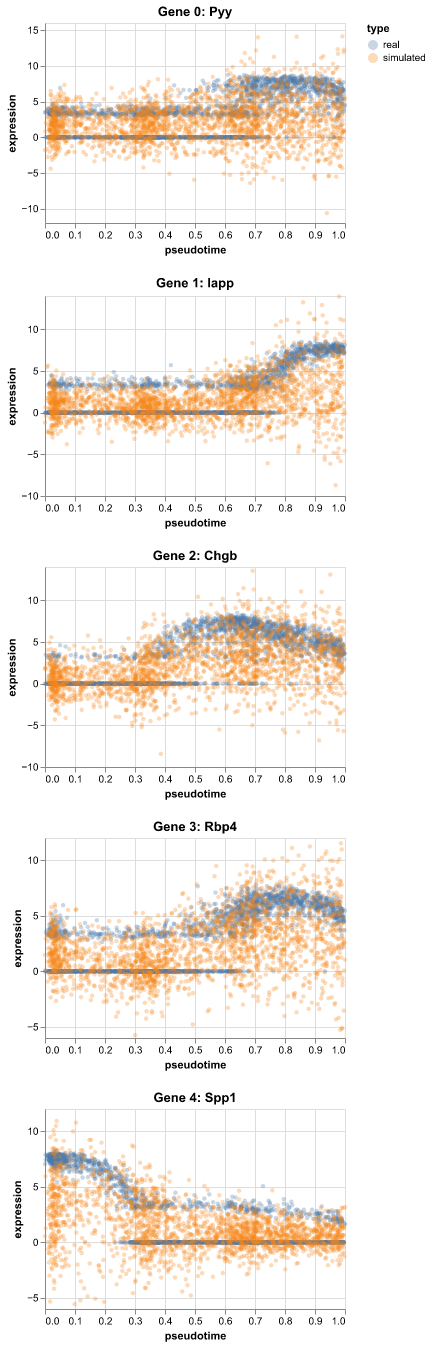

In [159]:
compare_gene_expression(gaussian_sim, gaussian_sce, num_genes=5, var="pseudotime")

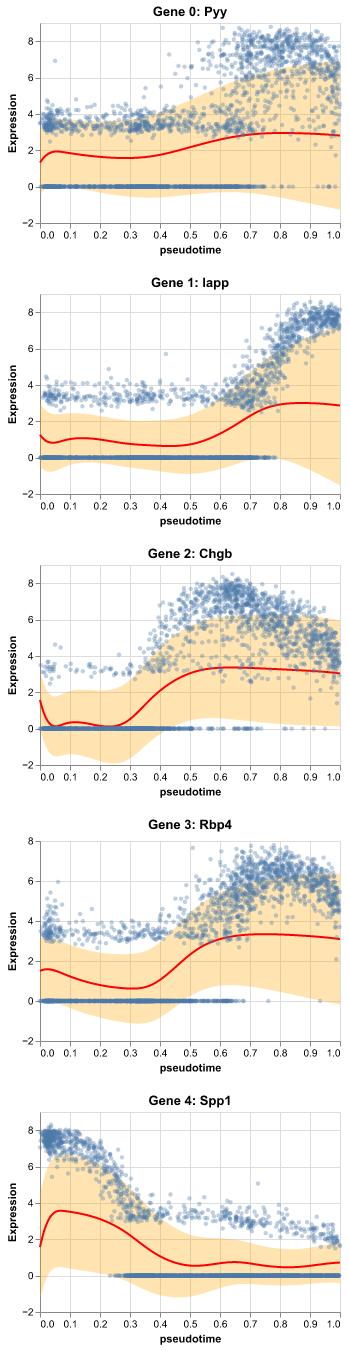

In [160]:
# n_sdev=1 gives the central approximately 68% Gaussian prediction band.
visualize_gaussian_expression(
    gaussian_sim, gaussian_sce, num_genes=5, var="pseudotime", n_sdev=1
)